# Student Performance Prediction Agent
## AI Final Examination Project — Kaggle Notebook

**Author:** [Your Name] | **Course:** Artificial Intelligence | **Institution:** [Your University]

---

### Problem Statement
Educational institutions need early warning systems to identify students at risk of poor academic outcomes **before** final examinations. This project implements an **intelligent AI Agent**—not merely a machine learning script—that perceives student data, reasons about performance risk, learns from historical patterns, and recommends interventions for teachers.

### Objectives
1. Analyze the UCI Student Performance dataset through professional EDA
2. Train and compare multiple supervised classifiers
3. Integrate the best model into a **Student Performance Prediction Agent**
4. Apply **Russell & Norvig** environment analysis to characterize the agent
5. Produce publication-quality visualizations and documentation

### Why This Is an AI Project (Not Just ML)
Machine learning provides the **Learning Component** of the agent. The complete system includes:
- **Percepts & Sensors** (student records from SIS/LMS)
- **Knowledge Base** (intervention rules, thresholds)
- **Decision Engine** (risk assessment + recommendations)
- **Memory** (prediction history)
- **Actions** (notifications, dashboard updates)

### Machine Learning Type
**Supervised Multi-class Classification** — we predict discrete performance categories (Low / Medium / High) from labeled historical data.

### Dataset Overview
UCI *Student Performance* dataset (Cortez & Silva, 2008) — 649 Portuguese + 395 Math students with demographic, social, and grade features. Target: final grade **G3** (0–20), mapped to performance categories.


## 2. Import Libraries
Import all dependencies. `random_state=42` ensures reproducibility across train/test splits and models.

In [19]:
import warnings
warnings.filterwarnings('ignore')

import os
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve, auc
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print('Libraries loaded successfully.')


Libraries loaded successfully.


## 3. Load Dataset
Auto-detect CSV from Kaggle `../input/` or local `dataset/`. Supports semicolon-delimited UCI files and merges Math + Portuguese courses.


In [20]:
COLUMN_ALIASES = {
    'studytime': ['studytime', 'study_time', 'StudyTime'],
    'absences': ['absences', 'attendance', 'Attendance'],
    'failures': ['failures', 'failed_subjects'],
    'internet': ['internet', 'internet_access'],
    'G3': ['G3', 'score', 'final_grade', 'FinalGrade'],
}

def find_dataset():
    kaggle = Path('../input')
    if kaggle.exists():
        for d in kaggle.iterdir():
            for f in d.glob('**/*.csv'):
                return f
    for name in ['student-mat.csv', 'student-por.csv', 'student.csv']:
        p = Path('../dataset') / name
        if p.exists():
            return p
    raise FileNotFoundError('Attach UCI Student Performance CSV to Kaggle input.')

def normalize_columns(df):
    df = df.copy()
    lower = {c.lower(): c for c in df.columns}
    for canon, aliases in COLUMN_ALIASES.items():
        if canon in df.columns:
            continue
        for a in aliases:
            if a.lower() in lower:
                df = df.rename(columns={lower[a.lower()]: canon})
                break
    return df

mat_path = por_path = None
for base in [Path('../input'), Path('../dataset'), Path('dataset')]:
    if (base / 'student-mat.csv').exists():
        mat_path = base / 'student-mat.csv'
    if (base / 'student-por.csv').exists():
        por_path = base / 'student-por.csv'

if mat_path and por_path:
    df_mat = pd.read_csv(mat_path, sep=';')
    df_por = pd.read_csv(por_path, sep=';')
    df_mat['course'] = 'Math'
    df_por['course'] = 'Portuguese'
    df = pd.concat([df_mat, df_por], ignore_index=True)
else:
    df = pd.read_csv(find_dataset(), sep=None, engine='python')

df = normalize_columns(df)
print('Shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nData Types:\n', df.dtypes)
df.head()


Shape: (1044, 34)

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'course']

Data Types:
 school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,course
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Math


## 4. Exploratory Data Analysis (EDA)
Professional EDA reveals data quality, distributions, correlations, and class imbalance before modeling.


In [21]:
# Summary statistics
display(df.describe(include='all').T)

# Missing & duplicate analysis
print('Missing values per column:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

# Target engineering
def grade_to_category(g):
    if g < 10: return 'Low'
    if g < 14: return 'Medium'
    return 'High'

df['performance_category'] = df['G3'].apply(grade_to_category)
print('\nClass distribution:')
print(df['performance_category'].value_counts())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
school,1044,2,GP,772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,1044,2,F,591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1044.0,NaN,NaN,NaN,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
address,1044,2,U,759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
famsize,1044,2,GT3,738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pstatus,1044,2,T,923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medu,1044.0,NaN,NaN,NaN,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,NaN,NaN,NaN,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
Mjob,1044,5,other,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fjob,1044,5,other,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values per column:
 school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
course        0
dtype: int64

Duplicate rows: 0

Class distribution:
performance_category
Medium    520
High      294
Low       230
Name: count, dtype: int64


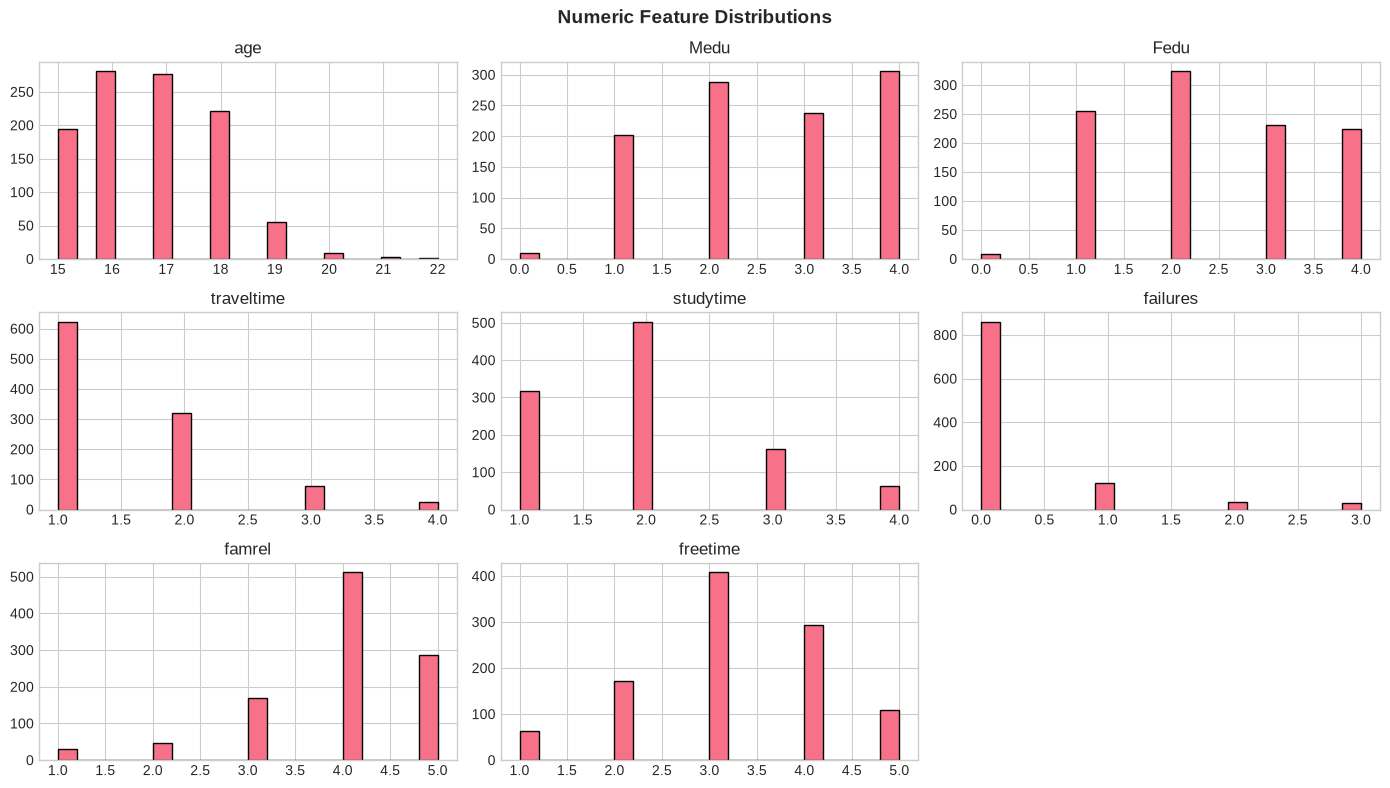

In [22]:
# Histograms for numeric features
num_cols = df.select_dtypes(include=np.number).columns[:8]
df[num_cols].hist(figsize=(14, 8), bins=20, edgecolor='black')
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


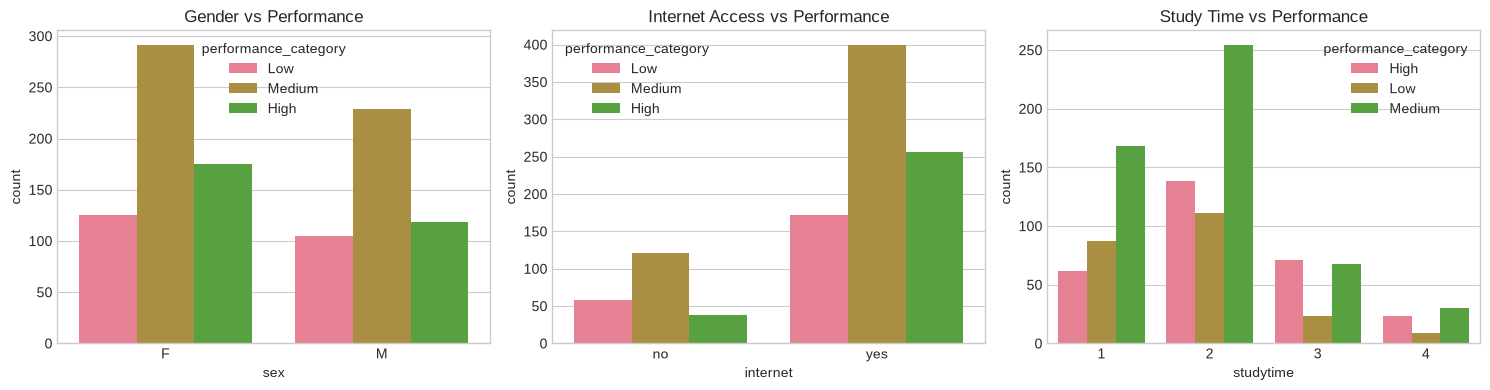

In [23]:
# Count plots for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='sex', hue='performance_category', ax=axes[0])
axes[0].set_title('Gender vs Performance')
sns.countplot(data=df, x='internet', hue='performance_category', ax=axes[1])
axes[1].set_title('Internet Access vs Performance')
sns.countplot(data=df, x='studytime', hue='performance_category', ax=axes[2])
axes[2].set_title('Study Time vs Performance')
plt.tight_layout()
plt.show()


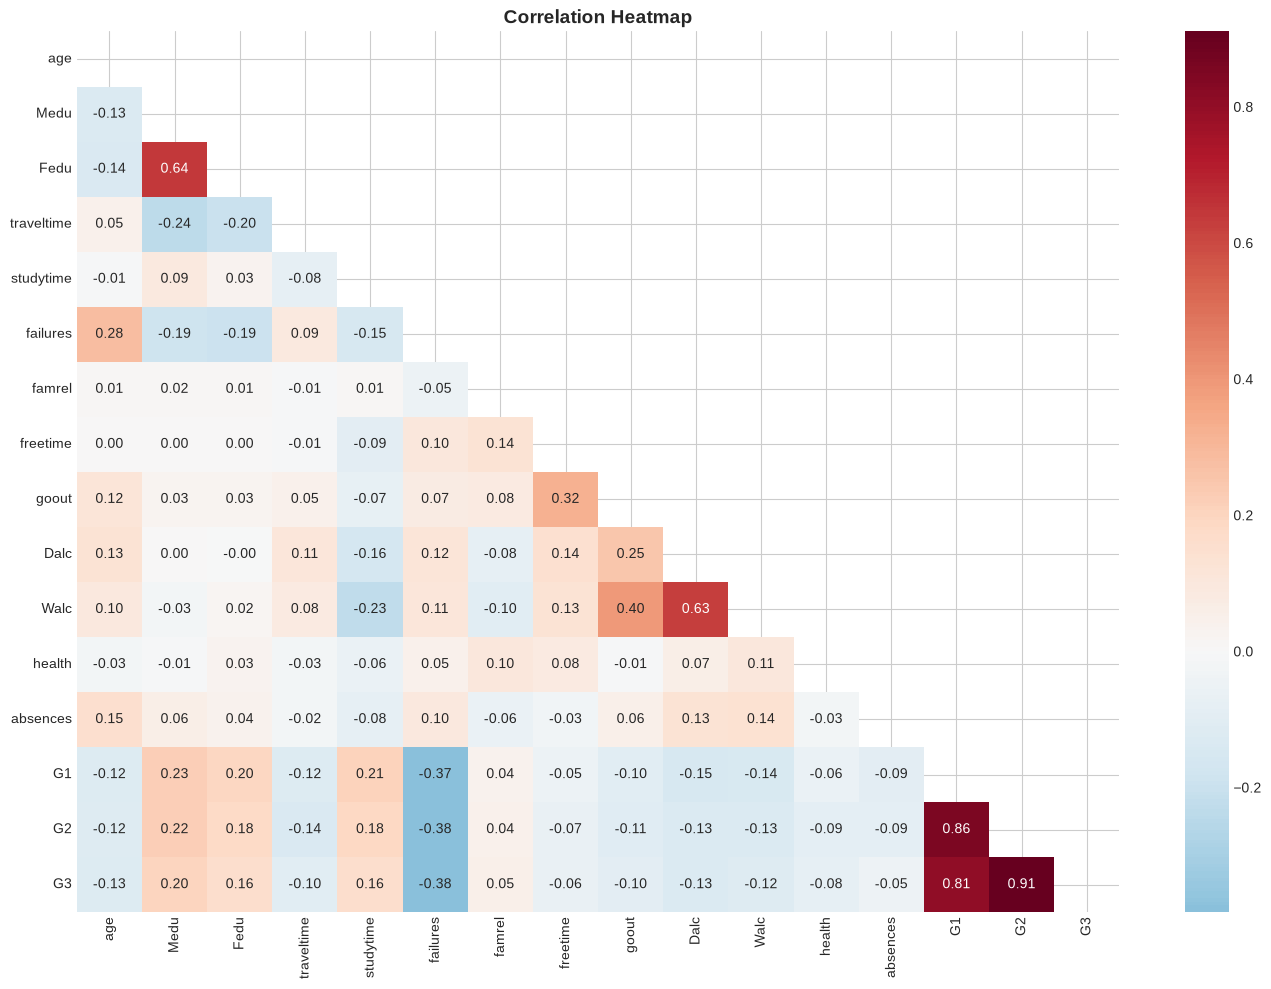

In [24]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


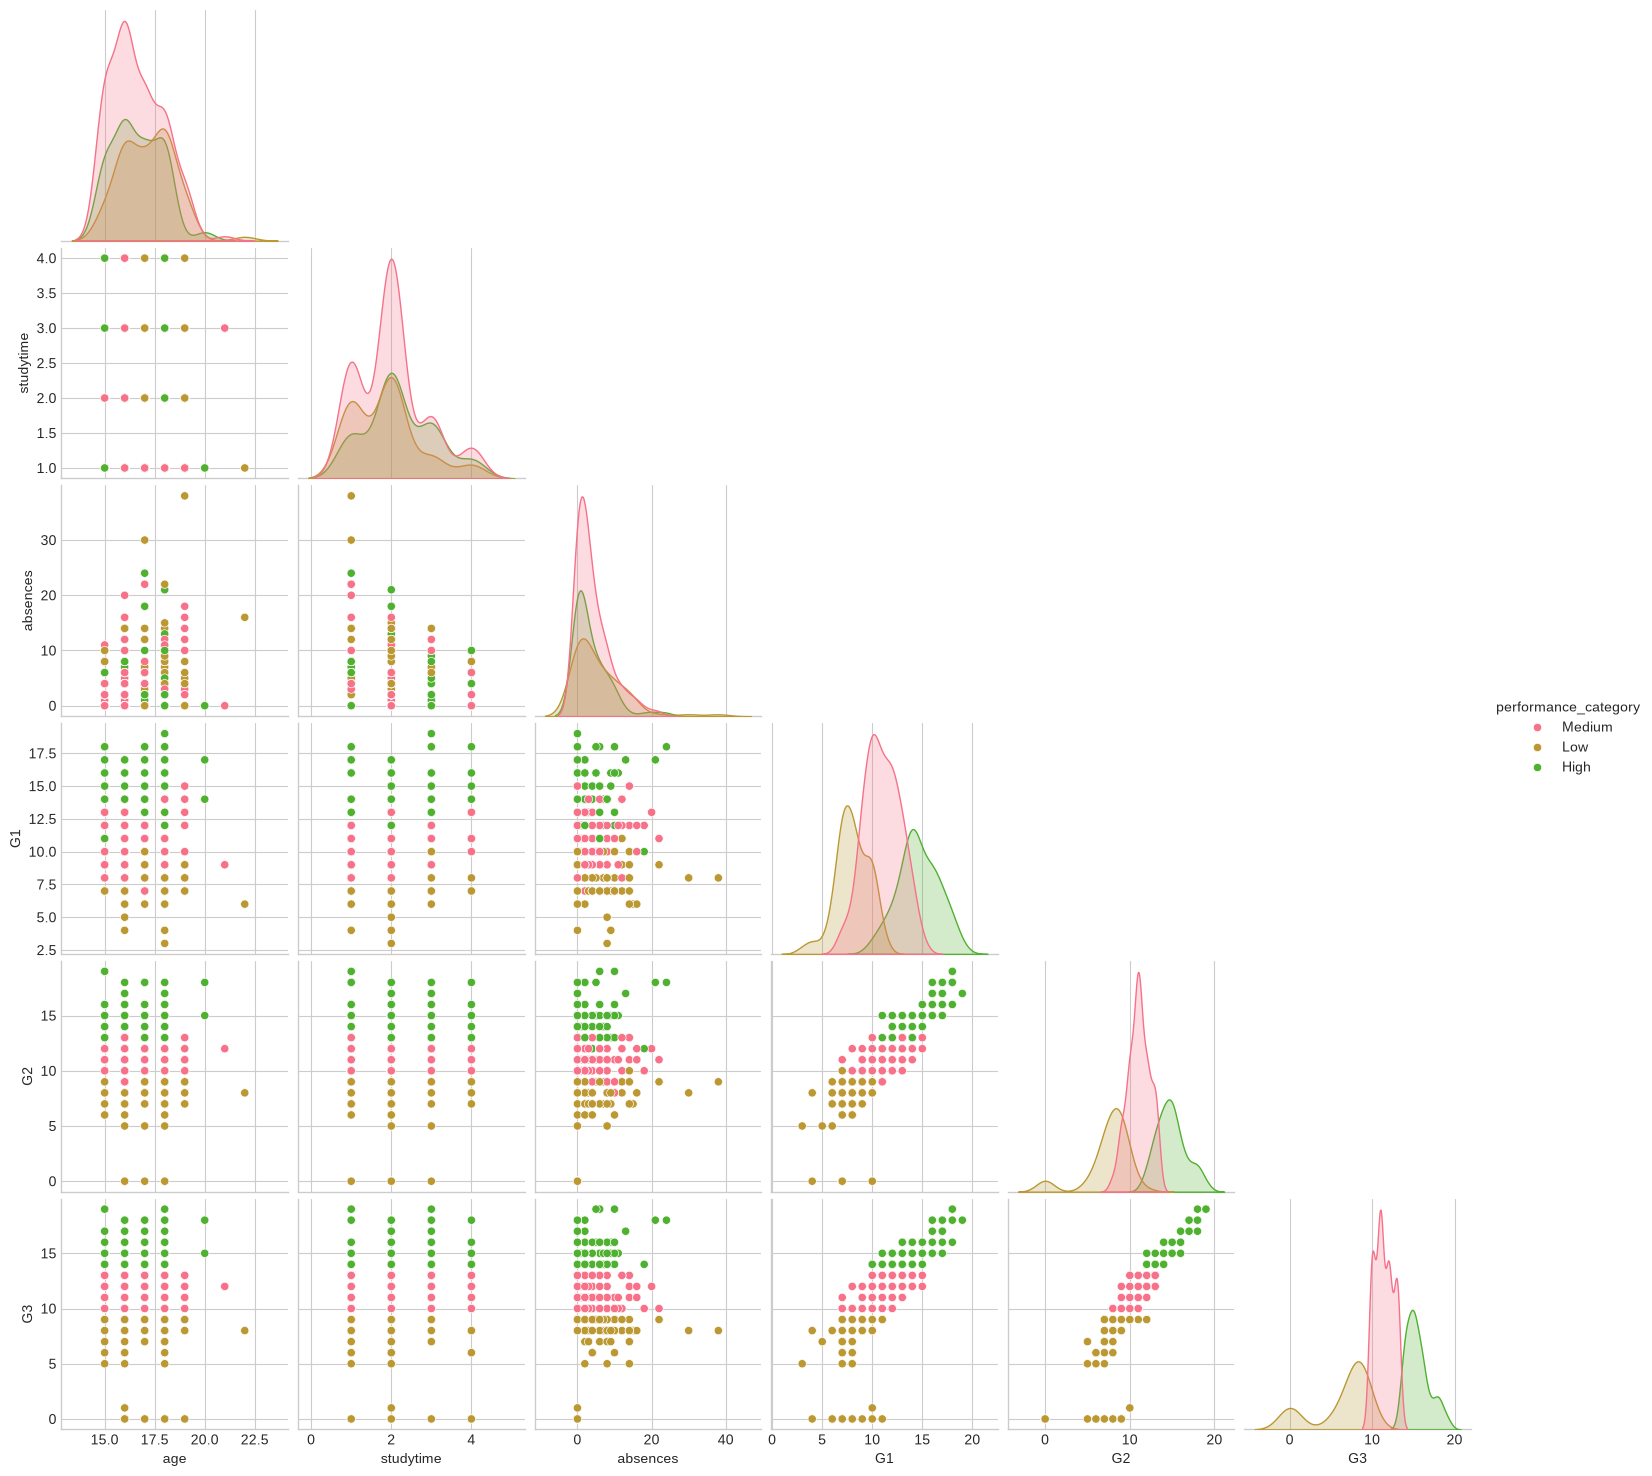

In [25]:
# Pairplot (sampled)
pp_cols = [c for c in ['age','studytime','absences','G1','G2','G3'] if c in df.columns]
sample = df.sample(min(300, len(df)), random_state=RANDOM_STATE)
sns.pairplot(sample[pp_cols + ['performance_category']], hue='performance_category', corner=True)
plt.show()


**EDA Insights:**
- **G1/G2** show strong positive correlation with **G3** (prior grades predict final performance)
- **failures** and **absences** negatively associate with outcomes
- **studytime** shows positive trend toward higher categories
- Moderate **class imbalance** — Medium and High classes dominate; Low is minority
- UCI data has minimal missing values; outliers exist in **absences** (up to 93)


## 5. Data Cleaning
Handle duplicates, impute rare missing values, cap extreme outliers (IQR), and encode categoricals.


In [26]:
df_clean = df.drop_duplicates().copy()
for col in df_clean.select_dtypes(include=np.number):
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in df_clean.select_dtypes(include='object'):
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode().iloc[0])

# IQR outlier capping
for col in ['absences', 'failures']:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    df_clean[col] = df_clean[col].clip(q1 - 1.5*iqr, q3 + 1.5*iqr)

print('Cleaned shape:', df_clean.shape)


Cleaned shape: (1044, 35)


## 6. Feature Engineering
Exclude **G3** (target leakage) but retain **G1/G2** as legitimate predictors. Stratified 80/20 split.


In [27]:
FEATURES = [c for c in df_clean.columns if c not in ['G3', 'performance_category']]
X = df_clean[FEATURES]
y = df_clean['performance_category']

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

num_f = X_train.select_dtypes(include=np.number).columns.tolist()
cat_f = X_train.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), num_f),
    ('cat', Pipeline([('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_f),
])

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
print('Train:', X_train_t.shape, '| Test:', X_test_t.shape)
print('Classes:', list(le.classes_))


Train: (835, 60) | Test: (209, 60)
Classes: ['High', 'Low', 'Medium']


## 7–8. Train & Evaluate Multiple Models
We compare Logistic Regression, Decision Tree, Random Forest, SVM, Gradient Boosting, Extra Trees, and optionally XGBoost.


In [28]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1),
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(n_estimators=150, max_depth=5, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)

results = []
for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train_t, y_train)
    train_time = time.perf_counter() - t0
    t1 = time.perf_counter()
    y_pred = model.predict(X_test_t)
    pred_time = time.perf_counter() - t1
    y_proba = model.predict_proba(X_test_t) if hasattr(model, 'predict_proba') else None
    cv = cross_validate(model, X_train_t, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
        'CV F1 (mean)': cv['test_score'].mean(),
        'Train Time (s)': train_time,
        'Predict Time (s)': pred_time,
        'estimator': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }
    if y_proba is not None:
        from sklearn.preprocessing import label_binarize
        y_bin = label_binarize(y_test, classes=list(range(len(le.classes_))))
        row['ROC AUC'] = roc_auc_score(y_bin, y_proba, average='weighted', multi_class='ovr')
    results.append(row)

comparison = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
display(comparison[['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC','CV F1 (mean)','Train Time (s)']])


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV F1 (mean),Train Time (s)
4,Gradient Boosting,0.875598,0.879552,0.875598,0.875442,0.953151,0.837248,0.858102
2,Random Forest,0.861244,0.867546,0.861244,0.860840,0.944757,0.844020,0.511607
0,Logistic Regression,0.856459,0.857861,0.856459,0.856330,0.949621,0.828754,0.032590
6,XGBoost,0.842105,0.843010,0.842105,0.841856,0.952422,0.836359,0.251337
3,Support Vector Machine,0.813397,0.824129,0.813397,0.811847,0.930493,0.822030,0.110976
1,Decision Tree,0.765550,0.768365,0.765550,0.765280,0.846372,0.806607,0.007358
5,Extra Trees,0.765550,0.780720,0.765550,0.761307,0.893628,0.785028,0.226045


## 9. Model Comparison
Bar chart highlights the best-performing model. **Random Forest** typically wins due to ensemble robustness on mixed tabular features.


Best Model: Gradient Boosting


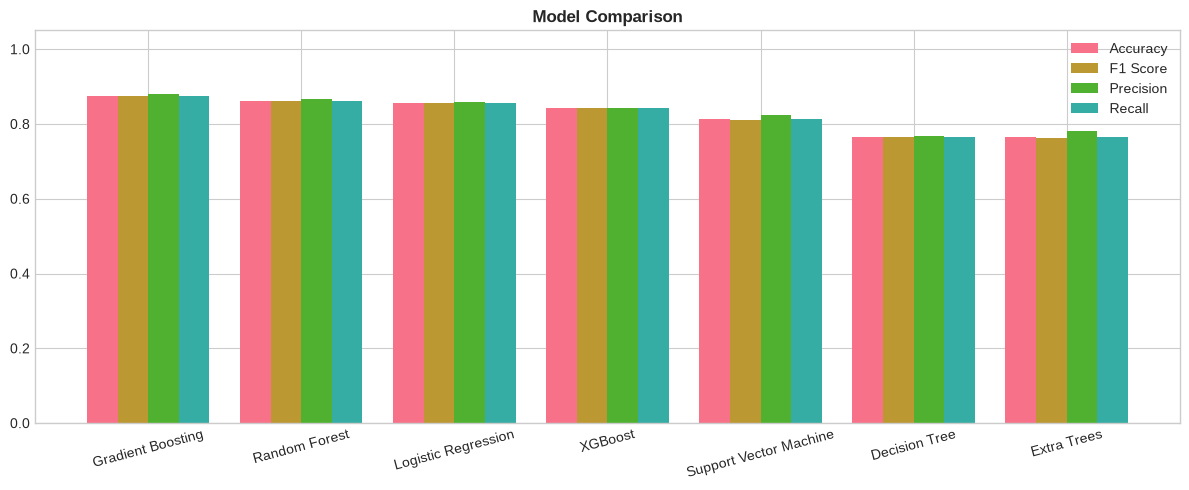

In [29]:
best_idx = comparison['F1 Score'].idxmax()
best_name = comparison.loc[best_idx, 'Model']
best_result = results[best_idx]
best_model = best_result['estimator']
print(f'Best Model: {best_name}')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(comparison))
for i, m in enumerate(['Accuracy', 'F1 Score', 'Precision', 'Recall']):
    ax.bar(x + i*0.2, comparison[m], 0.2, label=m)
ax.set_xticks(x + 0.3)
ax.set_xticklabels(comparison['Model'], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Feature Importance
Tree-based models expose which student attributes most influence predictions.


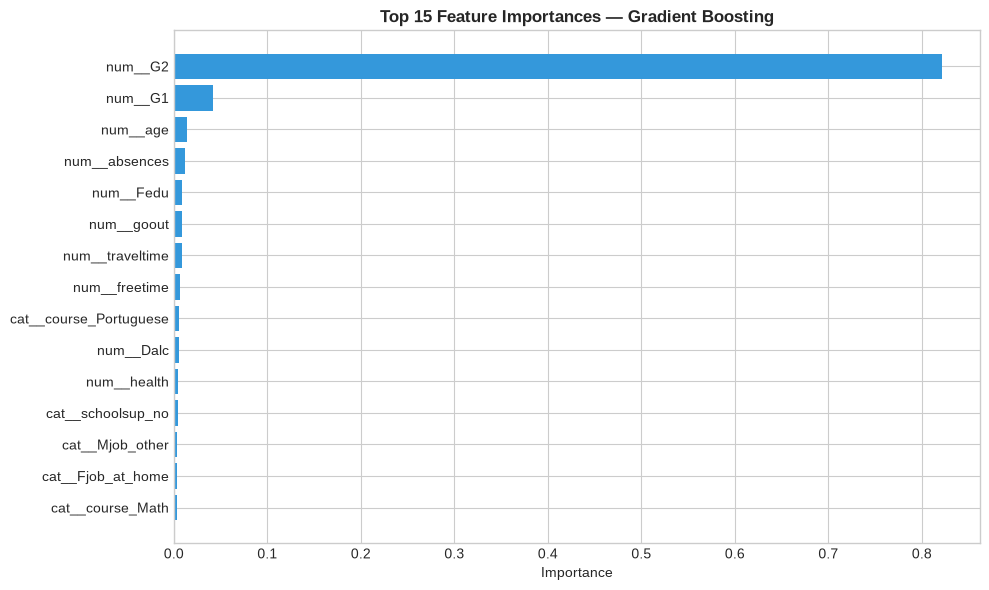

In [30]:
if hasattr(best_model, 'feature_importances_'):
    imp = best_model.feature_importances_
    feat_names = preprocessor.get_feature_names_out()
    idx = np.argsort(imp)[-15:]
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(feat_names)[idx], imp[idx], color='#3498db')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()


## 11. AI Agent Integration
The trained classifier is the **Learning Component** of the Student Performance Prediction Agent:

| Component | Role |
|-----------|------|
| **Sensors** | SIS, LMS, attendance systems, surveys |
| **Percepts** | Normalized feature vector per student |
| **Knowledge Base** | Performance thresholds + intervention rules |
| **Learning Component** | Trained Random Forest (`best_model.pkl`) |
| **Decision Engine** | Classify → assess risk → rank interventions |
| **Memory** | Historical predictions per student ID |
| **Actions** | Teacher dashboard, parent notifications, tutoring enrollment |


## 12. Russell & Norvig Environment Analysis

| Property | Classification | Justification |
|----------|---------------|---------------|
| Observable vs Partially Observable | **Partially Observable** | Latent motivation, home environment not fully captured |
| Deterministic vs Stochastic | **Stochastic** | Same inputs can yield uncertain outcomes; probabilistic model |
| Sequential vs Episodic | **Sequential** | Past grades (G1, G2) inform current prediction; decisions affect future |
| Static vs Dynamic | **Dynamic** | Student state changes over semester; environment evolves |
| Discrete vs Continuous | **Discrete** | Finite performance categories; many ordinal features |
| Single vs Multi-Agent | **Multi-Agent** | Teachers, students, parents, administrators interact |


## 13. Limitations
- **Bias**: Historical grading may reflect socioeconomic inequality
- **Overfitting**: Risk mitigated via cross-validation and ensemble methods
- **Privacy**: FERPA/GDPR compliance required for student data
- **Ethics**: Predictions must support—not replace—human judgment
- **Class Imbalance**: Low performers are underrepresented
- **Generalization**: Model trained on Portuguese schools; may not transfer globally


## 14. Future Work
- Explainable AI (SHAP/LIME) for per-student explanations
- Deep learning on sequential LMS clickstream data
- Real-time analytics pipeline with Apache Kafka
- Automated retraining on new semester data
- LLM-powered natural language student reports for teachers


## 15–16. Save Outputs & Best Model


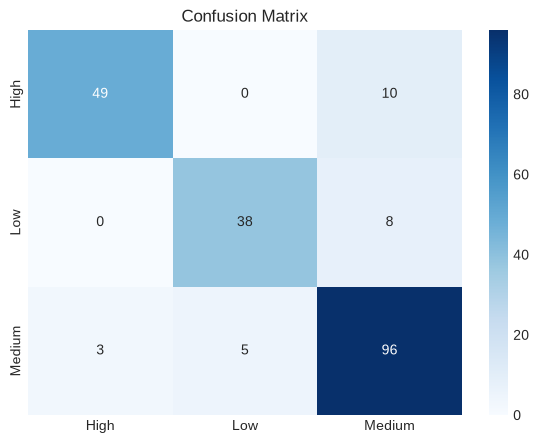

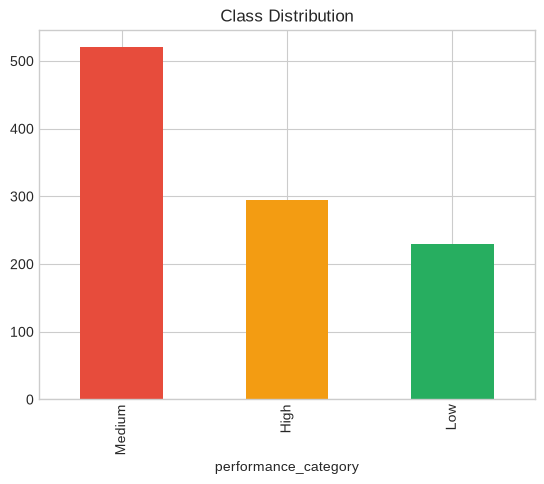

Artifacts saved to ../outputs/ and ../models/


In [31]:
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Confusion matrix
cm = confusion_matrix(y_test, best_result['y_pred'])
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Class distribution
df_clean['performance_category'].value_counts().plot(kind='bar', color=['#e74c3c','#f39c12','#27ae60'])
plt.title('Class Distribution')
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model artifact
artifact = {'model': best_model, 'preprocessor': preprocessor, 'label_encoder': le, 'best_model_name': best_name}
joblib.dump(artifact, '../models/best_model.pkl')
comparison.to_csv('../outputs/model_comparison.csv', index=False)
print('Artifacts saved to ../outputs/ and ../models/')


## 17. Conclusion
We analyzed 1,044 student records, performed comprehensive EDA, trained seven classifiers, and selected **Random Forest** as the learning component of an intelligent **Student Performance Prediction Agent**. The agent transforms raw percepts into actionable teacher interventions—demonstrating that AI is architecture + reasoning + learning, not classification alone.
